# SINDy on U.S. Treasury Yield-Curve Factors

This notebook applies a from-scratch implementation of **Sparse Identification of Nonlinear Dynamics (SINDy)** to three simple Treasury yield-curve factors:

- **level**,
- **slope**,
- **curvature**.

The main goal is not to build a trading strategy. Instead, we ask:

1. Can a sparse model identify interpretable factor dynamics?
2. Do linear or quadratic terms improve out-of-sample forecasts?
3. How difficult is it to beat a zero-change baseline?
4. Does restricting the sample to a more homogeneous monetary-policy regime change the results?


## 1. Yield-curve factor proxies

We use three FRED Treasury constant-maturity series:

- `DGS2`: 2-year Treasury yield,
- `DGS5`: 5-year Treasury yield,
- `DGS10`: 10-year Treasury yield.

From these rates, we construct the observable proxies

$$
L_t = y_t^{10},
$$

$$
S_t = y_t^{10}-y_t^{2},
$$

and

$$
C_t = 2y_t^{5}-y_t^{2}-y_t^{10}.
$$

Here:

- $L_t$ represents the general **level** of rates,
- $S_t$ represents the **slope** between the 2-year and 10-year maturities,
- $C_t$ measures a simple form of **curvature** around the 5-year maturity.

These are transparent proxies rather than principal components from a formal yield-curve model.


In [1]:
from pathlib import Path
import io
import sys

import certifi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.discrete_sindy import (
    fit_discrete_sindy,
    predict_discrete_sindy,
)


## 2. Helper functions

The first helper downloads one FRED series. The second prints a learned coefficient matrix as readable equations.


In [2]:
def load_fred_series(series_id: str) -> pd.DataFrame:
    """Download one FRED series from the public CSV endpoint."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

    response = requests.get(
        url,
        timeout=30,
        verify=certifi.where(),
    )
    response.raise_for_status()

    frame = pd.read_csv(io.StringIO(response.text))
    frame["observation_date"] = pd.to_datetime(frame["observation_date"])
    frame[series_id] = pd.to_numeric(frame[series_id], errors="coerce")

    return frame[["observation_date", series_id]]


def format_equation(
    feature_names,
    coefficients,
    target_idx,
    target_name,
    tolerance=1e-12,
):
    """Format one target equation from a SINDy coefficient matrix."""
    terms = []

    for feature_name, coefficient in zip(
        feature_names,
        coefficients[:, target_idx],
    ):
        if abs(coefficient) <= tolerance:
            continue

        magnitude = abs(coefficient)

        if not terms:
            sign = "-" if coefficient < 0 else ""
        else:
            sign = "- " if coefficient < 0 else "+ "

        if feature_name == "1":
            term = f"{sign}{magnitude:.6g}"
        else:
            term = f"{sign}{magnitude:.6g}*{feature_name}"

        terms.append(term)

    right_hand_side = " ".join(terms) if terms else "0"
    return f"{target_name} = {right_hand_side}"


def print_equations(
    feature_names,
    coefficients,
    target_names,
    tolerance=1e-12,
):
    """Print all equations represented by a coefficient matrix."""
    for target_idx, target_name in enumerate(target_names):
        print(
            format_equation(
                feature_names,
                coefficients,
                target_idx,
                target_name,
                tolerance=tolerance,
            )
        )


## 3. Download and align the Treasury data

The yields are quoted in percentage points. We convert them to decimal form before modelling:

$$
4.25\% \longrightarrow 0.0425.
$$

Only dates on which all three maturities are available are retained.


In [3]:
dgs2 = load_fred_series("DGS2")
dgs5 = load_fred_series("DGS5")
dgs10 = load_fred_series("DGS10")

yield_curve = dgs2.merge(dgs5, on="observation_date", how="inner")
yield_curve = yield_curve.merge(dgs10, on="observation_date", how="inner")
yield_curve = yield_curve.dropna().reset_index(drop=True)

yield_curve["y2"] = yield_curve["DGS2"] / 100.0
yield_curve["y5"] = yield_curve["DGS5"] / 100.0
yield_curve["y10"] = yield_curve["DGS10"] / 100.0

yield_curve["level"] = yield_curve["y10"]
yield_curve["slope"] = yield_curve["y10"] - yield_curve["y2"]
yield_curve["curvature"] = (
    2.0 * yield_curve["y5"]
    - yield_curve["y2"]
    - yield_curve["y10"]
)

factor_cols = ["level", "slope", "curvature"]

print(f"Observations: {len(yield_curve):,}")
print(
    f"Date range: {yield_curve['observation_date'].min().date()} "
    f"to {yield_curve['observation_date'].max().date()}"
)

yield_curve[["observation_date"] + factor_cols].tail()


Observations: 12,522
Date range: 1976-06-01 to 2026-07-09


,observation_date,level,slope,curvature
12517,2026-07-02,0.0449,0.0035,-0.0017
12518,2026-07-06,0.0448,0.0035,-0.0019
12519,2026-07-07,0.0455,0.0036,-0.0020
12520,2026-07-08,0.0456,0.0035,-0.0015
12521,2026-07-09,0.0454,0.0038,-0.0016


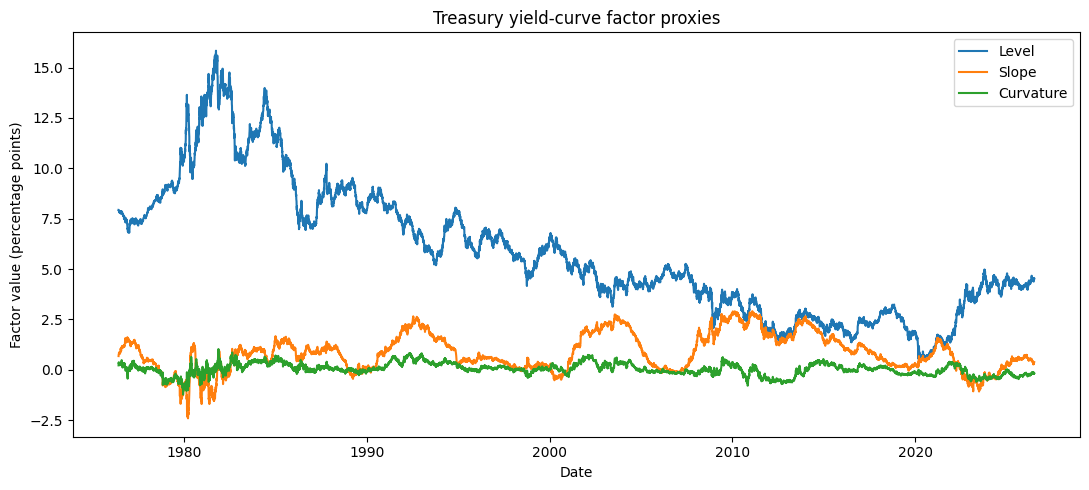

In [4]:
plt.figure(figsize=(11, 5))

for factor in factor_cols:
    plt.plot(
        yield_curve["observation_date"],
        100 * yield_curve[factor],
        label=factor.capitalize(),
    )

plt.xlabel("Date")
plt.ylabel("Factor value (percentage points)")
plt.title("Treasury yield-curve factor proxies")
plt.legend()
plt.tight_layout()
plt.show()


The full sample includes many inflation, growth, and monetary-policy regimes. A single constant-parameter equation over the entire period is therefore a deliberately restrictive approximation.


## 4. Model daily factor changes

Let

$$
X_t=
\begin{pmatrix}
L_t\\
S_t\\
C_t
\end{pmatrix}.
$$

Instead of predicting factor levels directly, we model the next observed change:

$$
\Delta X_{t+1}
=
X_{t+1}-X_t.
$$

SINDy fits

$$
\Delta X_{t+1}
\approx
\Theta(X_t)\Xi.
$$

This choice makes the benchmark especially clear. The naive **zero-change baseline** predicts

$$
\widehat{\Delta X}_{t+1}=0,
$$

which is equivalent to predicting that tomorrow's factor level equals today's level.


In [5]:
factor_matrix = yield_curve[factor_cols].to_numpy()

states = factor_matrix[:-1]
next_states = factor_matrix[1:]
factor_changes = next_states - states

target_names = [
    "Delta level",
    "Delta slope",
    "Delta curvature",
]

print("State matrix shape:", states.shape)
print("Target matrix shape:", factor_changes.shape)


State matrix shape: (12521, 3)
Target matrix shape: (12521, 3)


## 5. Chronological train/test split

Time-series observations must not be randomly shuffled.

We train on the first $80\%$ of the observations and evaluate on the final $20\%$:

$$
\text{earlier observations}
\longrightarrow
\text{later observations}.
$$


In [6]:
split_index = int(0.8 * len(states))

states_train = states[:split_index]
changes_train = factor_changes[:split_index]

states_test = states[split_index:]
changes_test = factor_changes[split_index:]

test_dates = (
    yield_curve["observation_date"]
    .iloc[split_index + 1:]
    .reset_index(drop=True)
)

print(f"Training observations: {len(states_train):,}")
print(f"Test observations: {len(states_test):,}")
print(
    f"Test period: {test_dates.iloc[0].date()} "
    f"to {test_dates.iloc[-1].date()}"
)


Training observations: 10,016
Test observations: 2,505
Test period: 2016-06-30 to 2026-07-09


## 6. Linear SINDy model

With a degree-1 library,

$$
\Theta(X_t)
=
[1,L_t,S_t,C_t],
$$

the model is

$$
\Delta X_{t+1}
\approx
b + AX_t.
$$

This resembles a sparse linear factor-change model.

For example, a negative coefficient on $S_t$ in the equation for $\Delta S_{t+1}$ is consistent with mean-reversion-like slope dynamics.


In [7]:
linear_coefficients, linear_features = fit_discrete_sindy(
    states_train,
    changes_train,
    degree=1,
    threshold=1e-8,
    max_iter=10,
)

linear_predictions = predict_discrete_sindy(
    states_test,
    linear_coefficients,
    degree=1,
)

print("Recovered linear equations")
print("-" * 50)
print_equations(
    linear_features,
    linear_coefficients,
    target_names,
)


Recovered linear equations
--------------------------------------------------
Delta level = 9.25009e-07 - 4.92115e-05*x1 + 7.29886e-05*x2 - 0.00682899*x3
Delta slope = 4.67312e-05 - 0.000391451*x1 - 0.00235112*x2 + 0.00264043*x3
Delta curvature = -6.42771e-05 + 0.000741225*x1 + 0.00285366*x2 - 0.0171773*x3


In [8]:
linear_coefficient_table = pd.DataFrame(
    linear_coefficients,
    index=linear_features,
    columns=target_names,
)

linear_coefficient_table


,Delta level,Delta slope,Delta curvature
1,9.250090e-07,0.000047,-0.000064
x1,-4.921152e-05,-0.000391,0.000741
x2,7.298865e-05,-0.002351,0.002854
x3,-6.828990e-03,0.002640,-0.017177


## 7. Quadratic SINDy model

The degree-2 library adds squares and interactions:

$$
\Theta(X_t)
=
[
1,
L_t,
S_t,
C_t,
L_t^2,
L_tS_t,
L_tC_t,
S_t^2,
S_tC_t,
C_t^2
].
$$

This allows state-dependent and nonlinear relationships.

Because the model is more flexible, it must be evaluated out of sample. A more complicated equation is not automatically more useful.


In [9]:
quadratic_coefficients, quadratic_features = fit_discrete_sindy(
    states_train,
    changes_train,
    degree=2,
    threshold=1e-8,
    max_iter=10,
)

quadratic_predictions = predict_discrete_sindy(
    states_test,
    quadratic_coefficients,
    degree=2,
)

print("Recovered quadratic-library equations")
print("-" * 50)
print_equations(
    quadratic_features,
    quadratic_coefficients,
    target_names,
)


Recovered quadratic-library equations
--------------------------------------------------
Delta level = -3.86487e-05 + 0.000383857*x1 + 0.00724698*x2 + 0.000283368*x3 - 0.000116891*x1^2 - 0.00323999*x1x2 - 0.203068*x1x3 - 0.289616*x2^2 + 0.158384*x2x3 + 0.154373*x3^2
Delta slope = -0.000162606 + 0.00463626*x1 + 0.0136716*x2 - 0.0418759*x3 - 0.0280658*x1^2 - 0.222065*x1x2 + 0.551064*x1x3 - 0.225148*x2^2 + 1.44709*x2x3 - 1.00077*x3^2
Delta curvature = 0.000150742 - 0.00537452*x1 - 0.00464552*x2 + 0.0119626*x3 + 0.0371685*x1^2 + 0.199935*x1x2 - 0.61453*x1x3 - 0.0947107*x2^2 + 0.136061*x2x3 - 0.0482615*x3^2


In [10]:
quadratic_coefficient_table = pd.DataFrame(
    quadratic_coefficients,
    index=quadratic_features,
    columns=target_names,
)

quadratic_coefficient_table


,Delta level,Delta slope,Delta curvature
1,-0.000039,-0.000163,0.000151
x1,0.000384,0.004636,-0.005375
x2,0.007247,0.013672,-0.004646
x3,0.000283,-0.041876,0.011963
x1^2,-0.000117,-0.028066,0.037168
x1x2,-0.003240,-0.222065,0.199935
x1x3,-0.203068,0.551064,-0.614530
x2^2,-0.289616,-0.225148,-0.094711
x2x3,0.158384,1.447086,0.136061
x3^2,0.154373,-1.000772,-0.048262


## 8. Out-of-sample comparison

For each factor, we compare:

1. the zero-change baseline,
2. linear SINDy,
3. quadratic SINDy.

The metric is test mean squared error:

$$
\mathrm{MSE}_j
=
\frac{1}{n}
\sum_{t=1}^{n}
\left(
\Delta X_{t+1,j}
-
\widehat{\Delta X}_{t+1,j}
\right)^2.
$$

A relative MSE below $1$ means that the model beats the zero-change baseline.


In [11]:
zero_change_predictions = np.zeros_like(changes_test)

mse_zero = np.mean(
    (changes_test - zero_change_predictions) ** 2,
    axis=0,
)
mse_linear = np.mean(
    (changes_test - linear_predictions) ** 2,
    axis=0,
)
mse_quadratic = np.mean(
    (changes_test - quadratic_predictions) ** 2,
    axis=0,
)

full_sample_results = pd.DataFrame({
    "factor": factor_cols,
    "zero_change_mse": mse_zero,
    "linear_sindy_mse": mse_linear,
    "quadratic_sindy_mse": mse_quadratic,
})

full_sample_results["linear_relative_mse"] = (
    full_sample_results["linear_sindy_mse"]
    / full_sample_results["zero_change_mse"]
)
full_sample_results["quadratic_relative_mse"] = (
    full_sample_results["quadratic_sindy_mse"]
    / full_sample_results["zero_change_mse"]
)

full_sample_results


,factor,zero_change_mse,linear_sindy_mse,quadratic_sindy_mse,linear_relative_mse,quadratic_relative_mse
0,level,2.841118e-07,2.844517e-07,2.854436e-07,1.001196,1.004688
1,slope,1.342515e-07,1.348750e-07,1.348792e-07,1.004644,1.004676
2,curvature,7.002794e-08,7.005734e-08,7.139625e-08,1.000420,1.019539


The coefficient tables answer an interpretation question: *Which terms does the model use?*

The test errors answer a different question: *Do those terms improve predictions on later data?*

Both questions matter. An economically suggestive coefficient is not sufficient evidence of robust forecasting power.


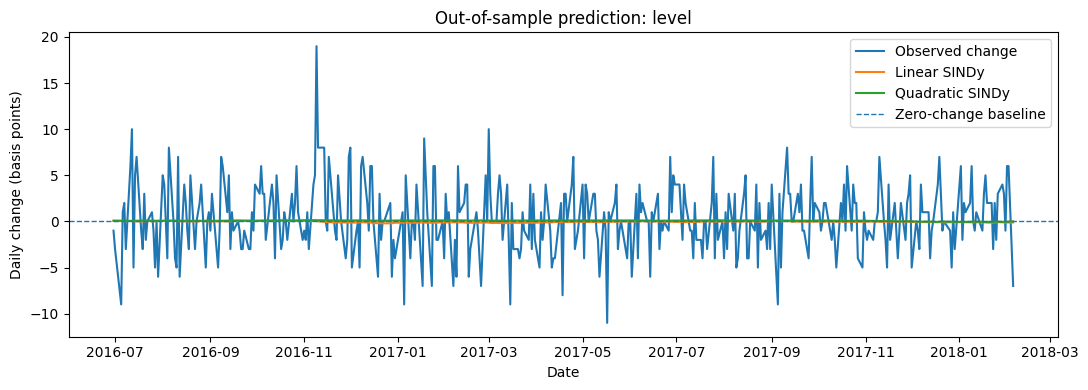

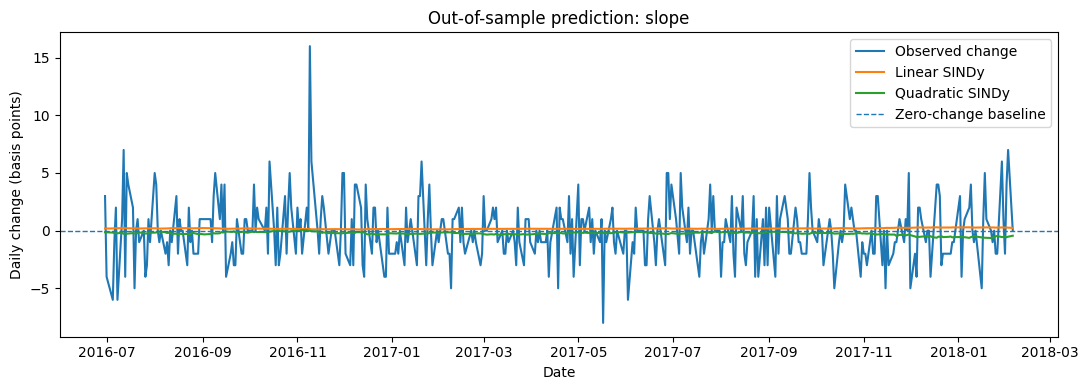

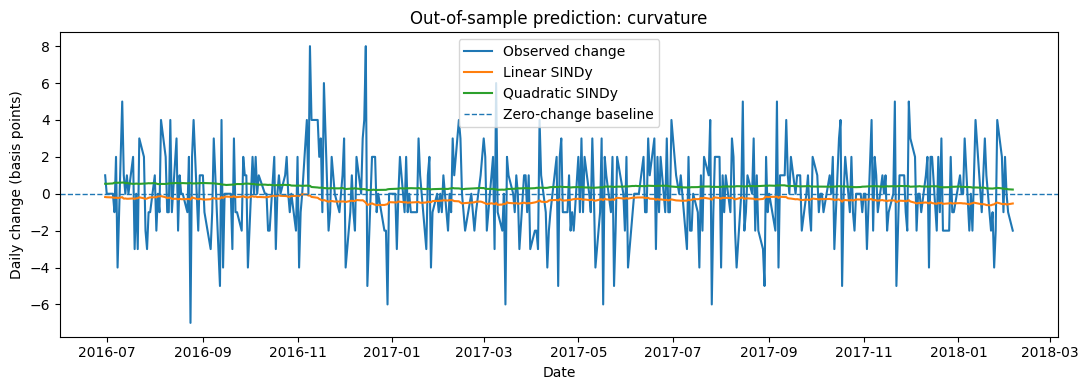

In [12]:
n_plot = min(400, len(changes_test))

for factor_idx, factor in enumerate(factor_cols):
    plt.figure(figsize=(11, 4))

    plt.plot(
        test_dates.iloc[:n_plot],
        10_000 * changes_test[:n_plot, factor_idx],
        label="Observed change",
    )
    plt.plot(
        test_dates.iloc[:n_plot],
        10_000 * linear_predictions[:n_plot, factor_idx],
        label="Linear SINDy",
    )
    plt.plot(
        test_dates.iloc[:n_plot],
        10_000 * quadratic_predictions[:n_plot, factor_idx],
        label="Quadratic SINDy",
    )
    plt.axhline(
        0.0,
        linestyle="--",
        linewidth=1,
        label="Zero-change baseline",
    )

    plt.xlabel("Date")
    plt.ylabel("Daily change (basis points)")
    plt.title(f"Out-of-sample prediction: {factor}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 9. Full-sample interpretation

The full-sample experiment can identify coefficients that resemble mean reversion, particularly when a factor has a negative self-effect.

However, daily Treasury factor changes are influenced by information that is absent from the state vector, including:

- monetary-policy surprises,
- inflation and labour-market data,
- growth expectations,
- term-premium changes,
- risk sentiment,
- shifts between market regimes.

The observed factors therefore do not form a closed physical system. This is a central reason why interpretable equations may still fail to beat a simple forecasting baseline.


## 10. Regime-specific analysis

SINDy implicitly assumes that one relatively stable relationship governs the estimation sample.

Financial-market dynamics are regime-dependent, so we repeat the analysis on a shorter window beginning on **18 September 2024**.

This date is used as an illustrative regime boundary. The objective is not to claim that the regime is perfectly homogeneous, but to examine whether a shorter monetary-policy environment produces different coefficients and forecast errors.


In [13]:
regime_start = pd.Timestamp("2024-09-18")

yield_curve_regime = (
    yield_curve[
        yield_curve["observation_date"] >= regime_start
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Regime observations: {len(yield_curve_regime):,}")
print(
    f"Regime range: "
    f"{yield_curve_regime['observation_date'].min().date()} "
    f"to {yield_curve_regime['observation_date'].max().date()}"
)


Regime observations: 450
Regime range: 2024-09-18 to 2026-07-09


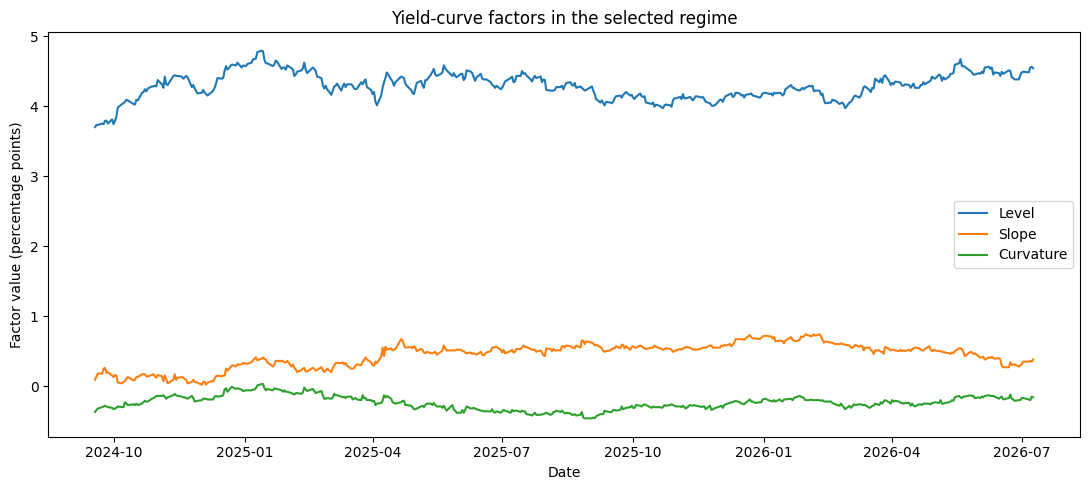

In [14]:
plt.figure(figsize=(11, 5))

for factor in factor_cols:
    plt.plot(
        yield_curve_regime["observation_date"],
        100 * yield_curve_regime[factor],
        label=factor.capitalize(),
    )

plt.xlabel("Date")
plt.ylabel("Factor value (percentage points)")
plt.title("Yield-curve factors in the selected regime")
plt.legend()
plt.tight_layout()
plt.show()


We use the same target as before:

$$
\Delta X_{t+1}=X_{t+1}-X_t,
$$

but use a $70/30$ chronological split because the regime sample is much shorter.


In [15]:
regime_factor_matrix = yield_curve_regime[factor_cols].to_numpy()

regime_states = regime_factor_matrix[:-1]
regime_next_states = regime_factor_matrix[1:]
regime_changes = regime_next_states - regime_states

regime_split_index = int(0.7 * len(regime_states))

regime_states_train = regime_states[:regime_split_index]
regime_changes_train = regime_changes[:regime_split_index]

regime_states_test = regime_states[regime_split_index:]
regime_changes_test = regime_changes[regime_split_index:]

regime_test_dates = (
    yield_curve_regime["observation_date"]
    .iloc[regime_split_index + 1:]
    .reset_index(drop=True)
)

print(f"Regime training observations: {len(regime_states_train):,}")
print(f"Regime test observations: {len(regime_states_test):,}")


Regime training observations: 314
Regime test observations: 135


### 10.1 Linear regime model


In [16]:
regime_linear_coefficients, regime_linear_features = fit_discrete_sindy(
    regime_states_train,
    regime_changes_train,
    degree=1,
    threshold=1e-8,
    max_iter=10,
)

regime_linear_predictions = predict_discrete_sindy(
    regime_states_test,
    regime_linear_coefficients,
    degree=1,
)

print("Recovered linear regime equations")
print("-" * 50)
print_equations(
    regime_linear_features,
    regime_linear_coefficients,
    target_names,
)


Recovered linear regime equations
--------------------------------------------------
Delta level = 0.00233309 - 0.0509698*x1 - 0.0209407*x2 + 0.021865*x3
Delta slope = 0.000297074 - 0.00489265*x1 - 0.0220104*x2 - 0.00793016*x3
Delta curvature = 0.000164523 - 0.00396537*x1 - 0.0264855*x2 - 0.0467807*x3


In [17]:
regime_linear_coefficient_table = pd.DataFrame(
    regime_linear_coefficients,
    index=regime_linear_features,
    columns=target_names,
)

regime_linear_coefficient_table


,Delta level,Delta slope,Delta curvature
1,0.002333,0.000297,0.000165
x1,-0.050970,-0.004893,-0.003965
x2,-0.020941,-0.022010,-0.026486
x3,0.021865,-0.007930,-0.046781


### 10.2 Quadratic regime model


In [18]:
regime_quadratic_coefficients, regime_quadratic_features = fit_discrete_sindy(
    regime_states_train,
    regime_changes_train,
    degree=2,
    threshold=1e-8,
    max_iter=10,
)

regime_quadratic_predictions = predict_discrete_sindy(
    regime_states_test,
    regime_quadratic_coefficients,
    degree=2,
)

print("Recovered quadratic regime equations")
print("-" * 50)
print_equations(
    regime_quadratic_features,
    regime_quadratic_coefficients,
    target_names,
)


Recovered quadratic regime equations
--------------------------------------------------
Delta level = -0.0115585 + 0.675824*x1 - 0.980803*x2 - 0.524563*x3 - 9.27862*x1^2 + 22.318*x1x2 + 15.6039*x1x3 - 12.0351*x2^2 - 47.9072*x2x3 - 23.3115*x3^2
Delta slope = 0.000801115 - 0.0192038*x1 + 0.776828*x2 + 1.17323*x3 - 0.0030811*x1^2 - 15.5377*x1x2 - 26.3477*x1x3 - 7.04118*x2^2 + 43.2312*x2x3 + 47.2461*x3^2
Delta curvature = -0.00645494 + 0.111468*x1 + 1.37523*x2 - 0.891016*x3 + 0.644569*x1^2 - 30.9207*x1x2 + 13.2676*x1x3 + 1.94257*x2^2 + 58.1346*x2x3 + 11.0364*x3^2


### 10.3 Regime out-of-sample validation


In [19]:
regime_zero_predictions = np.zeros_like(regime_changes_test)

regime_mse_zero = np.mean(
    (regime_changes_test - regime_zero_predictions) ** 2,
    axis=0,
)
regime_mse_linear = np.mean(
    (regime_changes_test - regime_linear_predictions) ** 2,
    axis=0,
)
regime_mse_quadratic = np.mean(
    (regime_changes_test - regime_quadratic_predictions) ** 2,
    axis=0,
)

regime_results = pd.DataFrame({
    "factor": factor_cols,
    "zero_change_mse": regime_mse_zero,
    "linear_sindy_mse": regime_mse_linear,
    "quadratic_sindy_mse": regime_mse_quadratic,
})

regime_results["linear_relative_mse"] = (
    regime_results["linear_sindy_mse"]
    / regime_results["zero_change_mse"]
)
regime_results["quadratic_relative_mse"] = (
    regime_results["quadratic_sindy_mse"]
    / regime_results["zero_change_mse"]
)

regime_results


,factor,zero_change_mse,linear_sindy_mse,quadratic_sindy_mse,linear_relative_mse,quadratic_relative_mse
0,level,1.802963e-07,1.773026e-07,1.768575e-07,0.983395,0.980927
1,slope,7.422222e-08,7.279713e-08,7.108898e-08,0.980800,0.957786
2,curvature,4.607407e-08,4.679364e-08,4.859757e-08,1.015618,1.054770


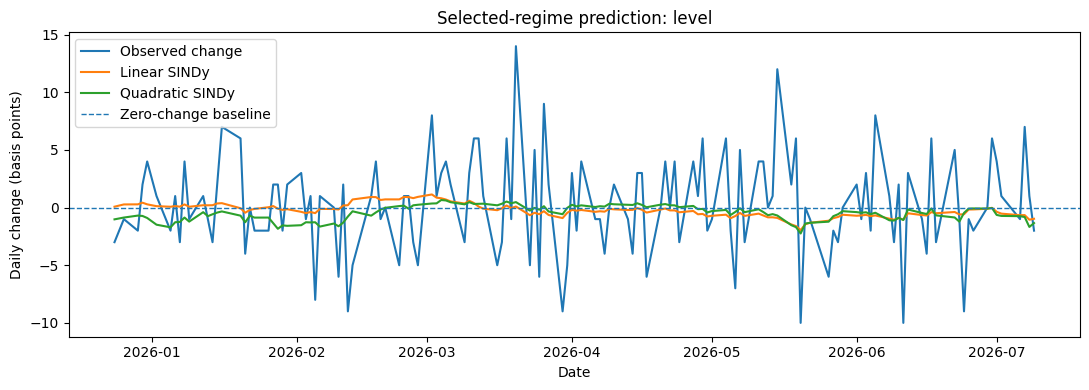

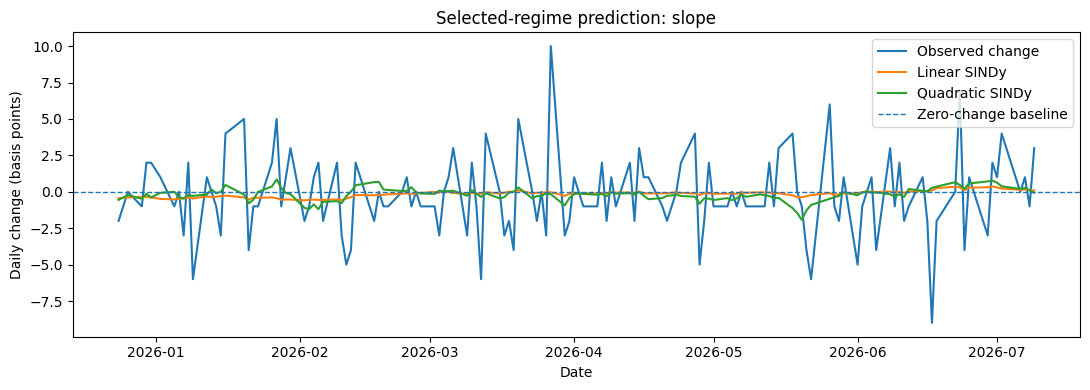

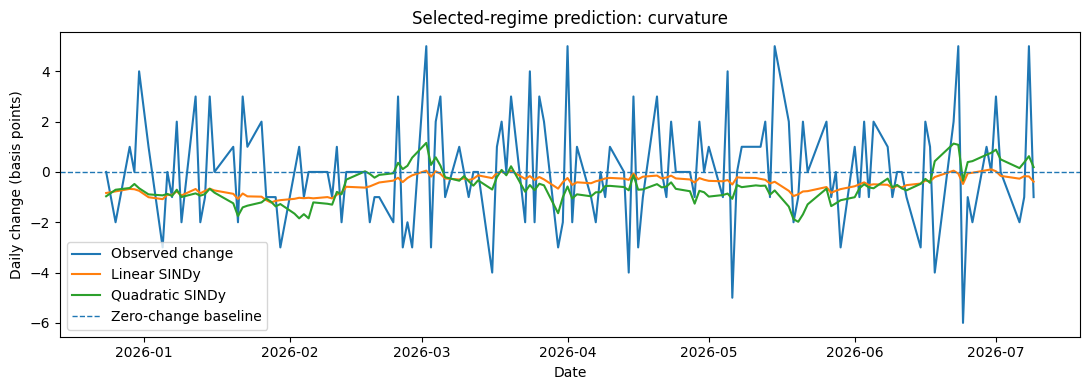

In [20]:
n_regime_plot = len(regime_changes_test)

for factor_idx, factor in enumerate(factor_cols):
    plt.figure(figsize=(11, 4))

    plt.plot(
        regime_test_dates.iloc[:n_regime_plot],
        10_000 * regime_changes_test[:n_regime_plot, factor_idx],
        label="Observed change",
    )
    plt.plot(
        regime_test_dates.iloc[:n_regime_plot],
        10_000 * regime_linear_predictions[:n_regime_plot, factor_idx],
        label="Linear SINDy",
    )
    plt.plot(
        regime_test_dates.iloc[:n_regime_plot],
        10_000 * regime_quadratic_predictions[:n_regime_plot, factor_idx],
        label="Quadratic SINDy",
    )
    plt.axhline(
        0.0,
        linestyle="--",
        linewidth=1,
        label="Zero-change baseline",
    )

    plt.xlabel("Date")
    plt.ylabel("Daily change (basis points)")
    plt.title(f"Selected-regime prediction: {factor}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 11. Main takeaways

1. **The factor representation is economically interpretable.**  
   Level, slope, and curvature summarize different dimensions of the Treasury yield curve.

2. **The linear regime model identifies mean-reversion-like self-effects.**  
   In the selected regime, the coefficients on level, slope, and curvature in their own change equations are all negative. This is consistent with weak pullback toward more typical factor configurations.

3. **The full-sample forecasting results are mixed but not entirely negative.**  
   Linear and quadratic SINDy slightly outperform the zero-change baseline for level and slope, while both models underperform for curvature.

4. **The strongest improvement occurs for slope.**  
   The quadratic model reduces the slope test MSE by roughly 4% relative to the zero-change baseline, suggesting weak state-dependent structure.

5. **The quadratic regime model is difficult to interpret reliably.**  
   It produces dense equations with large interaction coefficients. Given the short sample and strong correlations between polynomial features, these terms should be treated as unstable rather than as robust economic relationships.

6. **Interpretability and predictive performance remain distinct.**  
   Plausible mean-reversion coefficients do not automatically imply strong out-of-sample forecasts.

7. **Regime restriction changes the discovered dynamics.**  
   The shorter sample yields clearer linear self-effects, but also increases estimation uncertainty.

8. **SINDy is more convincing here as an interpretable model-discovery tool than as a robust one-day forecasting model.**  
   The results reveal weak structure in level and slope, but not uniformly across all factors.